In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

erreur q: 4.387598620773917e-05, erreur i: 0.01572610752382766
K: 0.0013347016023412227, erreur K: 4.695309623566461e-05
k: 1.3632786493897303e-10, erreur k: 1.6871152150712053e-13


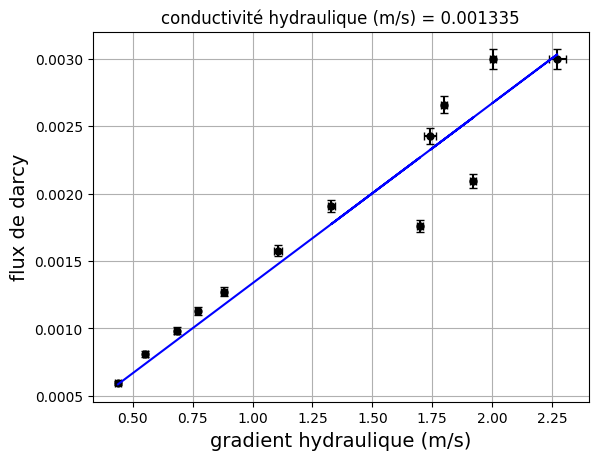

In [49]:
darcy_url = 'https://raw.githubusercontent.com/onillonn/TP_geologie/main/loi_darcy.xlsx'
darcy = pd.read_excel(darcy_url)
Q = darcy['débit_(m^3/s)'].dropna()
q = darcy['flux_Darcy_(m/s)'].dropna()
q_err = darcy['erreur_q'].dropna()
i = darcy['gradient'].dropna()
i_err = darcy['erreur_i'].dropna()

#Q_moy, q_moy, i_moy = np.mean(Q), np.mean(q), np.mean(i)
q_sigma, i_sigma = np.mean(q_err), np.mean(i_err)
print(f"erreur q: {q_sigma}, erreur i: {i_sigma}")

#graphe
fig, ax = plt.subplots()
ax.plot(i,q,'k',marker='o', linestyle='none',linewidth=0,markersize=5)
ax.errorbar(i,q,yerr=[q_err],xerr=[i_err],c='k',linestyle='none',capsize=3)
ax.set_xlabel('gradient hydraulique (m/s)',fontsize=14)
ax.set_ylabel('flux de darcy',fontsize=14)
ax.grid()
ax.set_title(f"conductivité hydraulique (m/s) = {K:.6f}")


#ligne de régression, K
from scipy.optimize import curve_fit
def function_for_fit(x,a): #fonction à ajouter, x est la variable, a le paramètre
    return a*x
popt,pcov = curve_fit(function_for_fit,i,q)
K = popt.squeeze()
K_err = np.sqrt(pcov).squeeze()
ax.plot(i,function_for_fit(i,K),'b')
print (f"K: {K}, erreur K: {K_err}")

#perméabilité intrinsèque
mu, rho, g = 0.001, 998, 9.81
k = K * mu / g / rho
k_err = k*((K_err/K)**2)
print (f"k: {k}, erreur k: {k_err}")



erreur q: 3.86751978773258e-05, erreur i: 0.014039802209780508
K: 0.0013019973829735598, erreur K: 6.334124982230618e-05
k: 1.329874206081439e-10, erreur k: 3.1474844770086336e-13


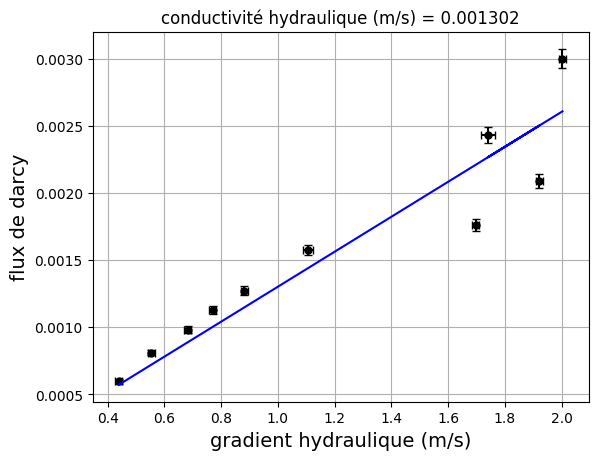

In [53]:
darcy_url = 'https://raw.githubusercontent.com/onillonn/TP_geologie/main/loi_darcy_corrige.xlsx'
darcy = pd.read_excel(darcy_url)
Q = darcy['débit_(m^3/s)'].dropna()
q = darcy['flux_Darcy_(m/s)'].dropna()
q_err = darcy['erreur_q'].dropna()
i = darcy['gradient'].dropna()
i_err = darcy['erreur_i'].dropna()

#Q_moy, q_moy, i_moy = np.mean(Q), np.mean(q), np.mean(i)
q_sigma, i_sigma = np.mean(q_err), np.mean(i_err)
print(f"erreur q: {q_sigma}, erreur i: {i_sigma}")

#graphe
fig, ax = plt.subplots()
ax.plot(i,q,'k',marker='o', linestyle='none',linewidth=0,markersize=5)
ax.errorbar(i,q,yerr=[q_err],xerr=[i_err],c='k',linestyle='none',capsize=3)
ax.set_xlabel('gradient hydraulique (m/s)',fontsize=14)
ax.set_ylabel('flux de darcy',fontsize=14)
ax.grid()
ax.set_title(f"conductivité hydraulique (m/s) = {K:.6f}")


#ligne de régression, K
from scipy.optimize import curve_fit
def function_for_fit(x,a): #fonction à ajouter, x est la variable, a le paramètre
    return a*x
popt,pcov = curve_fit(function_for_fit,i,q)
K = popt.squeeze()
K_err = np.sqrt(pcov).squeeze()
ax.plot(i,function_for_fit(i,K),'b')
print (f"K: {K}, erreur K: {K_err}")

#perméabilité intrinsèque
mu, rho, g = 0.001, 998, 9.81
k = K * mu / g / rho
k_err = k*((K_err/K)**2)
print (f"k: {k}, erreur k: {k_err}")